# Regresión Lógistica

* Solo nos sirve para clasificar en categorías.
* Por ejemplos, en base a un grupo de datos, clasificar si una persona tiene taquicardia, contra los que no.
* Las asignaciones pueden dar una probabilidad  de pertenecer a una clase.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Función Logística Estándar

* La función logística estándar es una función sigmoide que aparece con frecuencia en estadística, biología, aprendizaje automático y otras áreas. Se utiliza, por ejemplo, para modelar crecimiento poblacional, como función de activación en redes neuronales, o para modelar probabilidades (en regresión logística).
* Está función lo que hace es acotar los resultados entre 0 a 1, por lo mismo de las probabilidades.
$$
f(x) = \frac{1}{1 + e^{-x}}
$$
$$
x \in \mathbb{R}
$$

$$
e \approx 2.71828
$$

$$
f(x): \text{salida de la función logística}
$$
$$
\text{Dominio: } \mathbb{R}
$$

$$
\text{Rango: } (0, 1)
$$

$$
\lim_{x \to -\infty} f(x) = 0
$$

$$
\lim_{x \to +\infty} f(x) = 1
$$

$$
f(0) = \frac{1}{1 + e^0} = \frac{1}{2}
$$
$$
f'(x) = f(x) \cdot (1 - f(x))
$$
* Es una función sigmoide logística parametrizada, comúnmente utilizada para modelar probabilidades en regresión logística. Toma un valor real 𝑥 y lo transforma en un valor en el intervalo.
* El `bo + b1x` es la escuación de la recta y=mx +b.
* útil para:
   - Modelar probabilidades (por ejemplo, en clasificación binaria).
   - Crear activaciones en redes neuronales (aunque hoy en día se usa más ReLU).
   - Representar transiciones suaves entre dos estados.
* `𝑏0`: es el término independiente o sesgo (bias).
* `b1`: es el coeficiente que multiplica la entrada 𝑥.
* La función logística estándar es una forma especial del mismo tipo de función, pero sin parámetros.
$$
f(x) = \frac{1}{1 + e^{-(bo + b1x)}}
$$
* Una función sigmoide (o función sigmoidal) es una función matemática que tiene una forma característica de “S” suave (como una curva en forma de S alargada). El nombre proviene de la palabra griega "sigma", por la similitud visual con la letra "S".

### Código Regresión Logística

* Las funciones vectorizadas (también llamadas funciones vectoriales o funciones vectorizadas) son funciones diseñadas para operar sobre vectores (o matrices) de datos en lugar de hacerlo elemento por elemento, y son fundamentales para procesar grandes cantidades de datos de manera eficiente.
* Toma como entrada un vector (o matriz) de datos (por ejemplo, una lista de números)
* Devuelve otro vector (o matriz) aplicando una operación a todos los elementos a la vez, sin necesidad de bucles explícitos.
* `{lambda b0, b1, x : 1/ (1 + math.exp(-(b0+b1*x))), 3, 1}`: aquí mandamos 3 parametros, la función, la cantidad de argumentos, y los de regreso.
* `logistica (0,1, np.arange(-5,5,0.1))`: lo que estamos pasando es bo que es 'b', el b1 que es la pendiente 'm' y por ultimo el `np.arange(-5,5,0.1))` son los datos o rango para la gráfica.

<function matplotlib.pyplot.show(close=None, block=None)>

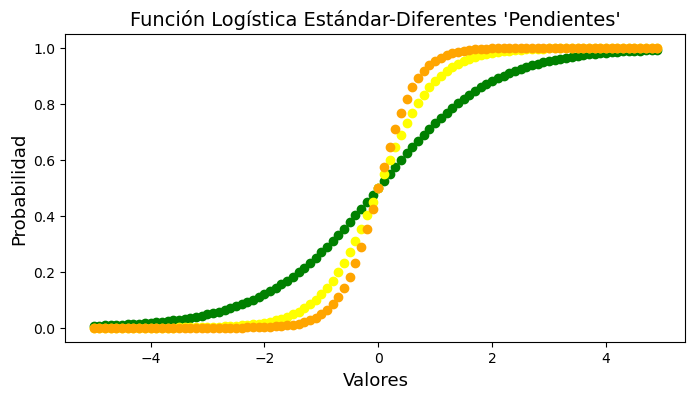

In [6]:
# Creamos una función logística vectorial (ufuncs)
# una función tradicional la convertimos en vectorizada.
logistica = np.frompyfunc(lambda b0, b1, x : 
                         1/ (1 + math.exp(-(b0+b1*x))),
                         3, 1)
# Graficamos la función logística con diferentes pendientes
plt.figure(figsize=(8,4))

plt.scatter(
    x = np.arange(-5,5,0.1),
    y = logistica (0,1, np.arange(-5,5,0.1)),
    color="green")

plt.scatter(
    x = np.arange(-5,5,0.1),
    y = logistica (0,2, np.arange(-5,5,0.1)),
    color="yellow")

plt.scatter(
    x = np.arange(-5,5,0.1),
    y = logistica (0,3, np.arange(-5,5,0.1)),
    color="orange")

plt.title("Función Logística Estándar-Diferentes 'Pendientes'", fontsize=14.0)
plt.ylabel("Probabilidad", fontsize=13.0)
plt.xlabel("Valores", fontsize=13.0)
plt.show

### Taquicardia: Probabilidad y clase

* Por ejemplo los primeros puntos verdes, tienen casi el 0% se sufrir problemas de taquicardia.
* Por su lado muchos puntos rojos tiene el 100% de sufrir taquicardia.
* Por otro lado vemos que en ambos vectores hay valores que pueden estár de por medio,  es decir, el 105 de la taquicardia, perfectamente pudiera estar en el vectro de las normales.
* Entonces todos estos valores tendrían un %51 por cierto de que tenga taquicardia o no.

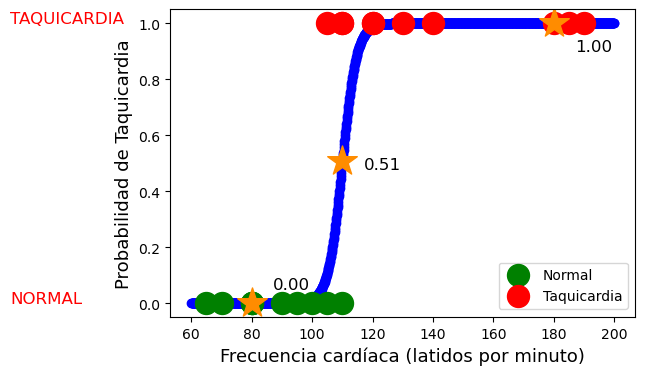

In [15]:
# Persona noral de 60 a 100 latidos por minuto.
# Persona con Taquicardia de hasta 220 latidos por minuto.
personas_normal = [65, 70, 80, 80, 80, 90, 95, 100, 105, 110]
persona_taquicardia = [105, 110, 110, 120, 120, 130, 140, 180, 185, 190]

# Graficamos una función logística
plt.figure(figsize=(6,4))

# Supongamos que el modelo sigue estos siguientes valores
"""
y = bo + b1x
y = -46.68057196 + 0.42460226x
"""
# Graficamos nuestras probilidades, es decir le modelo en si
plt.scatter(
    x = np.arange(60,200,0.1),
    y = logistica (-46.68057196,0.42460226, np.arange(60,200,0.1)),
    color="blue")

# Graficamos la frecuencia cardíaca de las personas
# solo estamos graficando puntos?
plt.scatter(
    x = personas_normal,
    y = [0]*10,
    marker="o",
    color="green",
    s=250,
    label="Normal"
)
plt.scatter(
    x = persona_taquicardia,
    y = [1]*10,
    marker="o",
    color="red",
    s=250,
    label="Taquicardia"
)

# Graficamos las probabilidades para 3 individuos
# Hacemos una clasificación en base a nuestro modelo.
individuos = [80, 110, 180]
probabilidades = logistica(-46.68057196,0.42460226,individuos)
plt.scatter(
    x = individuos,
    y = probabilidades,
    marker="*",
    color="darkorange",
    s=500,
)

plt.text(individuos[0]+7, 0.05, "%0.2f" % probabilidades[0], size=12, c="black")
plt.text(individuos[1]+7, 0.48, "%0.2f" % probabilidades[1], size=12, c="black")
plt.text(individuos[2]+7, 0.90, "%0.2f" % probabilidades[2], size=12, c="black")

plt.text(0,1, "TAQUICARDIA", size=12, color="red")
plt.text(0,0, "NORMAL", size=12, color="red")
plt.ylabel("Probabilidad de Taquicardia", fontsize=13.0)
plt.xlabel("Frecuencia cardíaca (latidos por minuto)", fontsize=13.0)
plt.legend(bbox_to_anchor=(1, 0.2))
plt.show()

### Máxima Verosimilitud

* Graficamos con varias pendientes, para ver como dependiendo de este, se puede aceptar más o menos el porcentaje de probabilidad de clasificación.
* Graficamos los mismos puntos, para ver como dependiendo de b1, es el % de clasificación

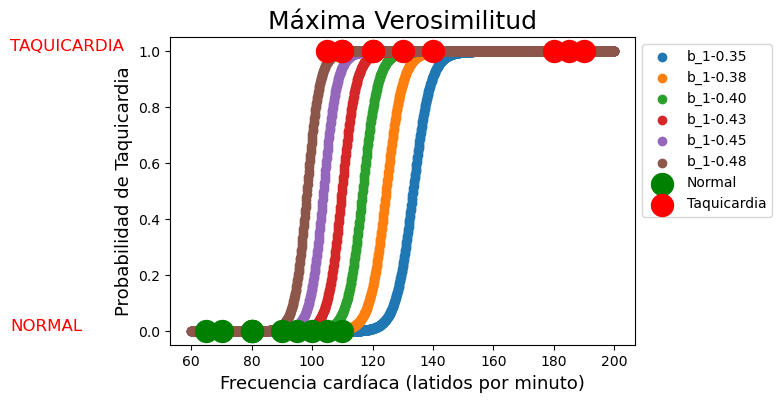

In [14]:
# Diferentes funciones logísticas con diferentes "pendientes"
plt.figure(figsize=(6,4))

for b1 in np.arange(0.35, 0.49, 0.025):
    plt.scatter(
        x = np.arange(60,200,0.1),
        y = logistica (-46.68057196,b1, np.arange(60,200,0.1)),
        label="b_1-%0.2f" % b1)

# Graficamos la frecuencia cardíaca de las personas
plt.scatter(personas_normal, [0]*10,
            marker="o", c="green", s=250, label="Normal")
plt.scatter(persona_taquicardia, [1]*10,
            marker="o", c="red", s=250, label="Taquicardia")

plt.title("Máxima Verosimilitud", fontsize=18.0)
plt.text(0,1, "TAQUICARDIA", size=12, color="red")
plt.text(0,0, "NORMAL", size=12, color="red")
plt.ylabel("Probabilidad de Taquicardia", fontsize=13.0)
plt.xlabel("Frecuencia cardíaca (latidos por minuto)", fontsize=13.0)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

### Modelo de Regresión Logística

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

frecuencias_cardiacas = [
    [65], [70], [80], [80], [80],
    [90], [95], [100], [105], [110],
    [105], [110], [110], [120], [120],
    [130], [140], [180], [185], [190]
]

clase = [
    0,0,0,0,0,0,0,0,0,0,
    1,1,1,1,1,1,1,1,1,1
]

# Creamos conjuntos de entrenamiento y de prueba del modelo
datos_entrena, datos_prueba, clase_entrena, clase_prueba = train_test_split(
    frecuencias_cardiacas,
    clase,
    test_size=0.30
)

# Creamos el modelo de Regresión Logística
modelo = LogisticRegression().fit(datos_entrena, clase_entrena)
np.set_printoptions(suppress=True)
print(modelo.predict(datos_prueba))
print(modelo.predict_proba(datos_prueba))
print(modelo.score(datos_prueba, clase_prueba))
print(modelo.intercept_, modelo.coef_)

[0 1 0 0 1 0]
[[0.99999994 0.00000006]
 [0.13247908 0.86752092]
 [0.99999994 0.00000006]
 [1.         0.        ]
 [0.00377997 0.99622003]
 [0.99597365 0.00402635]]
0.6666666666666666
[-75.71658788] [[0.73900765]]


### Suposiciones

* Dos clases
* No outliers (datos anómalos)
* Observaciones independientes
* No hay altas inter-correlaciones
* Muestra relativamente grande
* Relación lineal entre las probabilidades logarítmicas y las variables predictorias.